In [1]:
import os
os.chdir("/home/dlhogan/MTNHYDROSUMMA") # set working directory to your own path

import rioxarray as rxr
import xarray as xr
import geopandas as gpd
import py3dep
from pynhd import NLDI
from utils import get_spires_data
import matplotlib.pyplot as plt
from pathlib import Path
from dask import delayed, compute

In [2]:
gage_id = "09112500"  # East River near Almont, CO
basin = NLDI().get_basins("09112500").geometry.iloc[0]
topo = py3dep.get_map(["DEM", "Slope Degrees"], basin, 500, geo_crs=4326,)

### Download 2025 data

In [3]:
get_spires_data.download_spires_data(
    year=2025,
    months=["02","03","04","05","06"],
    product="NRT",
    tile="h09v05",
    destination_base="~/data/spires")

✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250201_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250202_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250203_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250204_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250205_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250206_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250207_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250208_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250209_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250210_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250211_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250212_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250213_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250214_V1.0.nc
✔️ Already exists: SPIRES_NRT_h09v05_MOD09GA061_20250215_V1.0.nc
✔️ Already exists: SPIRES

### Download 2024 Data

In [4]:
get_spires_data.download_spires_data(
    year=2024,
    months=["02","03","04","05","06"],
    product="HIST",
    tile="h09v05",
    destination_base="~/data/spires")

✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240201_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240202_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240203_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240204_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240205_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240206_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240207_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240208_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240209_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240210_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240211_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240212_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240213_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240214_V1.0.nc
✔️ Already exists: SPIRES_HIST_h09v05_MOD09GA061_20240215_V1.0.nc
✔️ Already

### Download historic data (to do later)
Can download back to 2000

### Clip data in parallel

In [5]:
year = 2024
input_dir = Path(f"/home/dlhogan/data/spires/{year}")
output_dir = Path(f"/home/dlhogan/data/spires_clipped/{year}")
output_dir.mkdir(parents=True, exist_ok=True)

gage_id = "09112500"
tasks = []

In [6]:
for ncfile in input_dir.glob("*.nc"):
    out_file = output_dir / ncfile.name
    if not out_file.exists():
        task = get_spires_data.clip_file_to_basin(ncfile, out_file, gage_id)
        tasks.append(task)

In [7]:
len(tasks)

0

In [8]:
# Trigger parallel processing
results = compute(*tasks, scheduler="processes", num_workers=2)  # or "threads"
for result in results:
    print(result)

In [9]:
clipped_files_2024 = sorted(Path(f"/home/dlhogan/data/spires_clipped/2024").glob("*.nc"))
ds_clipped_2024 = xr.open_mfdataset(clipped_files_2024, combine="by_coords")
ds_clipped_2024 = ds_clipped_2024.rio.write_crs("EPSG:4326")

In [10]:
clipped_files_2025 = sorted(Path(f"/home/dlhogan/data/spires_clipped/2025").glob("*.nc"))
ds_clipped_2025 = xr.open_mfdataset(clipped_files_2025, combine="by_coords")
ds_clipped_2025 = ds_clipped_2025.rio.write_crs("EPSG:4326")

In [11]:
# reproject elevation data to match the clipped dataset
elevation_reproj = topo.elevation.rio.reproject_match(ds_clipped_2024)
# establish elevation bands for analysis
elevation_bands = [2750, 3000, 3250, 3500, 3750, 4000]

# calculate the mean spires data for each elevation band
ds_clipped_2024['elevation'] = elevation_reproj
ds_clipped_2025['elevation'] = elevation_reproj

# groupby bins and calculate mean spires data
mean_spires_2024 = ds_clipped_2024.groupby_bins('elevation', bins=elevation_bands, labels=elevation_bands[:-1]).mean()
# filter out february 29
mean_spires_2024 = mean_spires_2024.where((mean_spires_2024['time.month'] != 2) | (mean_spires_2024['time.day'] != 29), drop=True)
mean_spires_2025 = ds_clipped_2025.groupby_bins('elevation', bins=elevation_bands, labels=elevation_bands[:-1]).mean()

In [31]:
mean_spires_2025

<xarray.Dataset> Size: 28kB
Dimensions:                         (elevation_bins: 5, time: 150)
Coordinates:
  * time                            (time) datetime64[ns] 1kB 2025-02-01T12:0...
    crs                             int64 8B 0
    spatial_ref                     int64 8B 0
  * elevation_bins                  (elevation_bins) int64 40B 2750 ... 3750
Data variables:
    viewable_snow_fraction          (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    grain_size                      (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    dust_concentration              (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    snow_fraction                   (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    snow_cover_duration             (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    albedo_dirty_flat               (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    radiative_forcing               (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    deltavis                        (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    albedo_dirty_terrain_corrected  (elevation_bins, time) float32 3kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    elevation                       (elevation_bins) float32 20B 2.883e+03 .....
Attributes: (12/35)
    id:                            10.7265/hs6b-zg21
    title:                         Near Real-Time MODIS/Terra L3 Global Daily...
    citation:                      Mandatory citation for any work, including...
    license:                       Creative Commons BY 4.0. You are free to (...
    summary:                       This dataset contains daily raster images ...
    source:                        MOD09GA Terra Collection 6 v061
    ...                            ...
    versionOf_SPIReS:              v2024.1.0
    versionOf_SPIReS_alternative:  v2024.0d
    versionOf_SPIReS_NSIDC:        v1.0
    date_created:                  2025-07-03T03:25:04+00:00
    date_modified:                 2025-07-03T03:25:04+00:00
    geospatial_bounds:             POLYGON((40.00000000 -117.48665604, 40.000...

### Compare fSCA at different elevation bands between 2024 and 2025

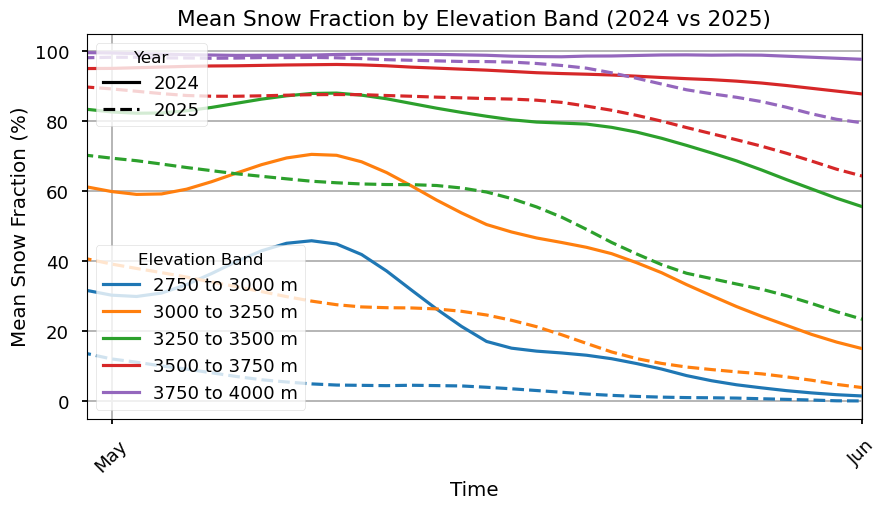

In [30]:
# plot a line for each elevation band
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(10,5))

lines_2024, = plt.plot([], [],  c='black')
lines_2025, = plt.plot([], [], linestyle='--', c='black')

# select 5 colors for a colorblind-friendly palette
colors = plt.cm.tab10.colors[:5]  # Use the first 5 colors from
for i,band in enumerate(elevation_bands[:-1]):
    plt.plot(mean_spires_2025['time'].values, 
            mean_spires_2024.isel(elevation_bins=i)['snow_fraction'].squeeze().values, 
            label=f'{elevation_bands[i]} to {elevation_bands[i+1]} m', 
            c=colors[i])
    plt.plot(mean_spires_2025['time'].values, 
    mean_spires_2025.isel(elevation_bins=i)['snow_fraction'].squeeze().values, linestyle='--', c=colors[i])

plt.xlabel('Time')
# change x-tick labels to month names
plt.xticks(mean_spires_2025['time'][::30].values, mean_spires_2025['time'][::30].dt.strftime('%b').values, rotation=45)
plt.title('Mean Snow Fraction by Elevation Band (2024 vs 2025)')
plt.ylabel('Mean Snow Fraction (%)')

legend1 = plt.legend([lines_2024, lines_2025], ['2024', '2025'], title='Year', loc='upper left', title_fontsize='large')
plt.legend(title='Elevation Band', title_fontsize='large', loc='lower left')
plt.gca().add_artist(legend1)
plt.grid(which='both')
plt.xlim(mean_spires_2025['time'].sel(time=slice('2025-05-01', '2025-06-01')).values[0], 
         mean_spires_2025['time'].sel(time=slice('2025-05-01', '2025-06-01')).values[-1])
plt.show()


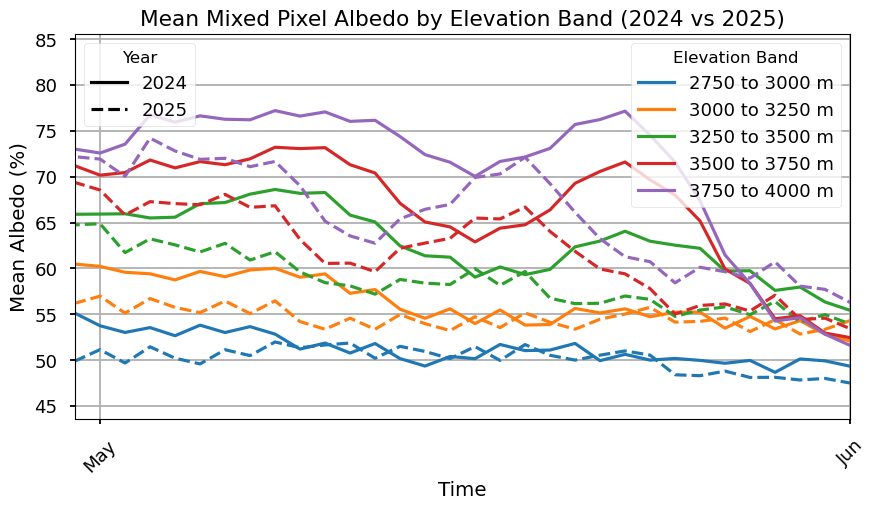

In [22]:
# plot a line for each elevation band
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(10,5))

lines_2024, = plt.plot([], [],  c='black')
lines_2025, = plt.plot([], [], linestyle='--', c='black')

# select 5 colors for a colorblind-friendly palette
colors = plt.cm.tab10.colors[:5]  # Use the first 5 colors from
for i,band in enumerate(elevation_bands[:-1]):
    plt.plot(mean_spires_2025['time'].values, 
            mean_spires_2024.isel(elevation_bins=i)['albedo_dirty_terrain_corrected'].squeeze().values, 
            label=f'{elevation_bands[i]} to {elevation_bands[i+1]} m', 
            c=colors[i])
    plt.plot(mean_spires_2025['time'].values, 
    mean_spires_2025.isel(elevation_bins=i)['albedo_dirty_terrain_corrected'].squeeze().values, linestyle='--', c=colors[i])

plt.xlabel('Time')
# change x-tick labels to month names
plt.xticks(mean_spires_2025['time'][::30].values, mean_spires_2025['time'][::30].dt.strftime('%b').values, rotation=45)
plt.title('Mean Mixed Pixel Albedo by Elevation Band (2024 vs 2025)')
plt.ylabel('Mean Albedo (%)')

legend1 = plt.legend([lines_2024, lines_2025], ['2024', '2025'], title='Year', loc='upper left', title_fontsize='large')
plt.legend(title='Elevation Band', title_fontsize='large')
plt.gca().add_artist(legend1)
plt.grid(which='both')
# make the xlim may 1 to jun 1
plt.xlim(mean_spires_2025['time'].sel(time=slice('2025-05-01', '2025-06-01')).values[0], 
         mean_spires_2025['time'].sel(time=slice('2025-05-01', '2025-06-01')).values[-1])
plt.show()
